# Train Part 2 (ML)
Notebook này là phần ML được tách ra từ `train_part2_modeling.ipynb`.
Mục tiêu: train/evaluate các model sklearn trên `features_hrv.csv`.


In [109]:
# 1) Setup & Imports
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
FEATURE_DIR = Path(r"C:\Users\buck\Napplee\StressClassification\data\features")
FEATURE_FILE = FEATURE_DIR / "features_hrv.csv"
ARTIFACTS_DIR = Path("artifacts")
REPORTS_DIR = Path("reports")

for p in [FEATURE_DIR, ARTIFACTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Feature file: {FEATURE_FILE}")
print(f"Artifacts directory: {ARTIFACTS_DIR.resolve()}")

Feature file: C:\Users\buck\Napplee\StressClassification\data\features\features_hrv.csv
Artifacts directory: C:\Users\buck\Napplee\StressClassification\artifacts


## Part A — Classical ML on extracted features
- Dùng các feature HRV/engineered (`features_hrv.csv`) để train các mô hình ML (RandomForest, SVM, Logistic, ...).
- Đây là nhánh "ML" như bạn yêu cầu.

In [110]:
LABEL_CANDIDATES = ["label", "Label", "stress", "stress_level", "target", "class"]

def find_label_column(df_in: pd.DataFrame):
    for c in LABEL_CANDIDATES:
        if c in df_in.columns:
            return c
    return None

def standardize_features_df(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    out = out.loc[:, ~out.columns.astype(str).str.startswith("Unnamed:")].copy()

    label_col = find_label_column(out)
    if label_col is None:
        raise ValueError(
            "Khong tim thay cot label trong feature dataset. Can mot trong cac cot: "
            + ", ".join(LABEL_CANDIDATES)
        )
    if label_col != "label":
        out = out.rename(columns={label_col: "label"})

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Feature dataset rong sau khi loai bo dong thieu label.")

    if "source_file" not in out.columns:
        out["source_file"] = "precomputed_features"
    if "window_id" not in out.columns:
        out["window_id"] = np.arange(len(out))

    if out["label"].dtype == "O" or str(out["label"].dtype).startswith("category"):
        out["label"] = out["label"].astype(str).str.strip()
    else:
        out["label"] = pd.to_numeric(out["label"], errors="coerce")

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Khong con mau nao sau khi chuan hoa cot label.")

    return out

if not FEATURE_FILE.exists():
    raise FileNotFoundError(f"Missing feature file: {FEATURE_FILE}")

features_df = pd.read_csv(FEATURE_FILE)
features_df = standardize_features_df(features_df) 

# Ensure Stroop-derived features exist
if {'lf_power', 'hf_power'}.issubset(features_df.columns):
    denom = features_df['lf_power'].fillna(0) + features_df['hf_power'].fillna(0)
    with np.errstate(divide='ignore', invalid='ignore'):
        features_df['lf_nu'] = np.where(denom > 0, (features_df['lf_power'] / denom) * 100.0, np.nan)
        features_df['hf_nu'] = np.where(denom > 0, (features_df['hf_power'] / denom) * 100.0, np.nan)
if {'pnn50', 'n_peaks'}.issubset(features_df.columns) and 'nn50_count' not in features_df.columns:
    rr_count = features_df['n_peaks'].clip(lower=1) - 1
    features_df['nn50_count'] = np.round((features_df['pnn50'] / 100.0) * rr_count).astype('float')

print(f"Feature shape: {features_df.shape}")
print("Class distribution (label):")
print(features_df["label"].value_counts(dropna=False).sort_index())
display(features_df.head())

Feature shape: (720, 26)
Class distribution (label):
label
0    360
1    135
2    105
3    120
Name: count, dtype: int64


,source_file,window_id,label,mean_rr_ms,median_rr_ms,sdnn_ms,rmssd_ms,pnn50,heart_rate_bpm,n_peaks,...,voltage_max,voltage_skew,voltage_kurtosis,lf_power,hf_power,lf_hf_ratio,total_power,lf_nu,hf_nu,nn50_count
0,day_custom_segments_001.csv,0,0,711.804354,707.03125,85.078109,63.927008,36.406806,84.292825,2529,...,1.053639,1.162522,2.504950,5003.241286,4177.197204,1.197751,9182.160969,54.498936,45.501064,920.0
1,day_custom_segments_001.csv,1,0,712.470000,703.12500,95.205423,69.283021,36.079208,84.214072,2527,...,1.054846,1.155849,2.493953,5309.696358,4401.932970,1.206219,9712.397102,54.673590,45.326410,911.0
2,day_custom_segments_001.csv,2,0,688.687428,679.68750,86.204835,62.725454,31.750287,87.122252,2613,...,1.061179,1.176187,2.535932,4683.645821,3771.410698,1.241882,8456.790406,55.394613,44.605387,829.0
3,day_custom_segments_001.csv,3,0,687.388094,679.68750,82.480155,62.489784,31.677493,87.286935,2619,...,1.058122,1.180852,2.550214,4632.446901,3743.318519,1.237524,8376.871132,55.307744,44.692256,829.0
4,day_custom_segments_001.csv,4,0,762.432137,761.71875,88.718956,81.620784,44.467995,78.695529,2361,...,1.053725,1.154344,2.516540,6135.009650,5511.043813,1.113221,11647.587577,52.678872,47.321128,1049.0


Feature dataset preview:


,source_file,window_id,label,mean_rr_ms,median_rr_ms,sdnn_ms,rmssd_ms,pnn50,heart_rate_bpm,n_peaks,...,voltage_max,voltage_skew,voltage_kurtosis,lf_power,hf_power,lf_hf_ratio,total_power,lf_nu,hf_nu,nn50_count
0,day_custom_segments_001.csv,0,0,711.804354,707.03125,85.078109,63.927008,36.406806,84.292825,2529,...,1.053639,1.162522,2.504950,5003.241286,4177.197204,1.197751,9182.160969,54.498936,45.501064,920.0
1,day_custom_segments_001.csv,1,0,712.470000,703.12500,95.205423,69.283021,36.079208,84.214072,2527,...,1.054846,1.155849,2.493953,5309.696358,4401.932970,1.206219,9712.397102,54.673590,45.326410,911.0
2,day_custom_segments_001.csv,2,0,688.687428,679.68750,86.204835,62.725454,31.750287,87.122252,2613,...,1.061179,1.176187,2.535932,4683.645821,3771.410698,1.241882,8456.790406,55.394613,44.605387,829.0
3,day_custom_segments_001.csv,3,0,687.388094,679.68750,82.480155,62.489784,31.677493,87.286935,2619,...,1.058122,1.180852,2.550214,4632.446901,3743.318519,1.237524,8376.871132,55.307744,44.692256,829.0
4,day_custom_segments_001.csv,4,0,762.432137,761.71875,88.718956,81.620784,44.467995,78.695529,2361,...,1.053725,1.154344,2.516540,6135.009650,5511.043813,1.113221,11647.587577,52.678872,47.321128,1049.0



Describe numeric features:


,count,mean,std,min,25%,50%,75%,max
window_id,720.0,23.500000,13.863030,0.000000,11.750000,23.500000,35.250000,47.000000
label,720.0,0.979167,1.146251,0.000000,0.000000,0.500000,2.000000,3.000000
mean_rr_ms,720.0,689.997239,26.640087,612.167457,672.515511,691.605916,707.996767,773.184022
median_rr_ms,720.0,684.011502,27.288498,609.375000,664.062500,687.500000,703.125000,773.437500
sdnn_ms,720.0,80.608669,8.857271,52.337381,74.768653,80.794009,86.765628,103.376735
rmssd_ms,720.0,57.992322,9.207555,31.604845,51.007455,58.116869,64.774084,82.129566
pnn50,720.0,27.727542,8.100850,8.422506,21.191346,28.900108,34.256730,47.033534
heart_rate_bpm,720.0,87.087428,3.390868,77.601190,84.746150,86.754608,89.217285,98.012397
n_peaks,720.0,2612.568056,101.675249,2328.000000,2542.750000,2603.000000,2675.750000,2940.000000
duration_sec,720.0,1799.996094,0.000000,1799.996094,1799.996094,1799.996094,1799.996094,1799.996094


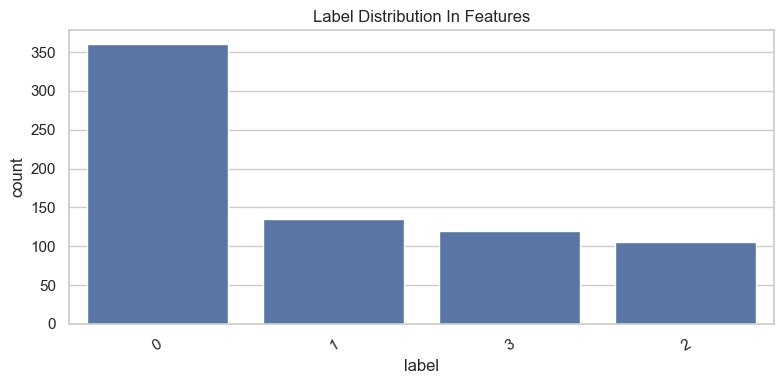

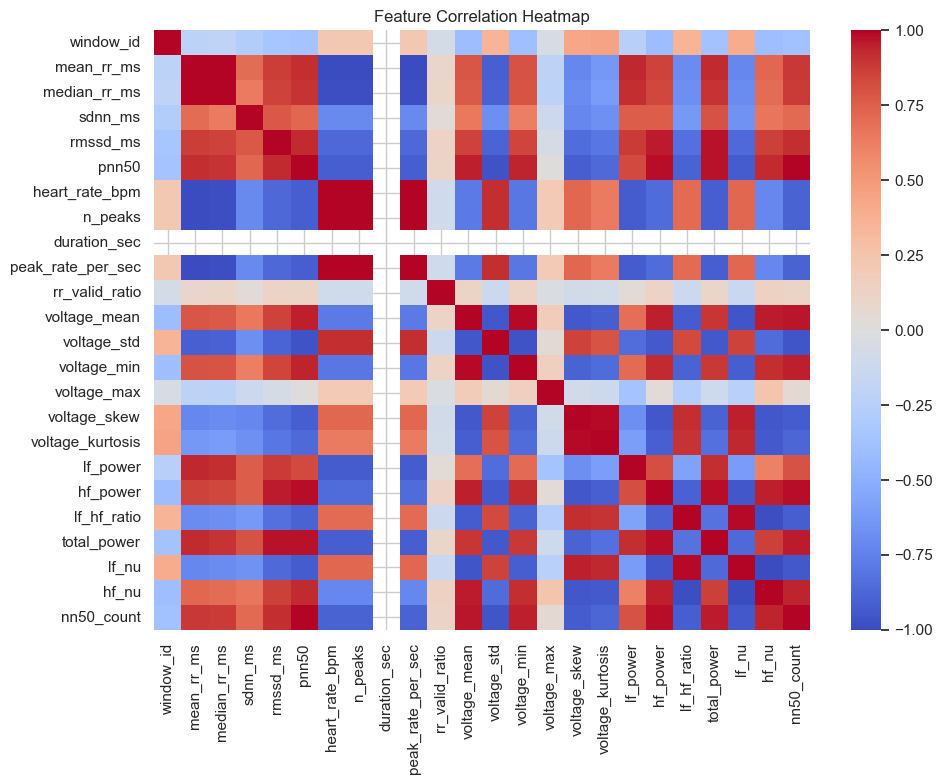

In [111]:
if "label" not in features_df.columns:
    raise ValueError("Khong co cot label trong features_df de train classifier.")

print("Feature dataset preview:")
display(features_df.head())

print("\nDescribe numeric features:")
display(features_df.describe(include=[np.number]).T.head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=features_df, x="label", order=features_df["label"].value_counts().index)
plt.title("Label Distribution In Features")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

num_cols = [c for c in features_df.select_dtypes(include=[np.number]).columns if c != "label"]
if len(num_cols) >= 2:
    plt.figure(figsize=(10, 8))
    sns.heatmap(features_df[num_cols].corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [112]:
EXPERIMENT_MODE = 'all'  # options: 'all', 'pure_only'
data_model = features_df.copy()
if EXPERIMENT_MODE == 'pure_only' and 'source_file' in data_model.columns:
    src_lower = data_model['source_file'].astype(str).str.lower()
    data_model = data_model[src_lower.str.contains('pure')].copy()
    print(f"Experiment mode: {EXPERIMENT_MODE} -> rows={len(data_model)}")
elif EXPERIMENT_MODE == 'all':
    print(f"Experiment mode: {EXPERIMENT_MODE} -> rows={len(data_model)}")
else:
    print(f"Experiment mode {EXPERIMENT_MODE} khong hop le hoac thieu source_file. Dung toan bo du lieu.")

# Cot giu de trace/ID, khong dua vao feature train
leakage_or_trace_cols = [c for c in ["source_file", "window_id"] if c in data_model.columns]
groups = data_model["source_file"].astype(str).values if "source_file" in data_model.columns else None

X = data_model.drop(columns=["label"] + leakage_or_trace_cols)
y_raw = data_model["label"]

if y_raw.nunique(dropna=True) < 2:
    raise ValueError("Target label chi co 1 lop, khong the train classifier.")

FEATURE_SET_MODE = "all_numeric"  # options: 'hrv_core', 'stroop', 'all_numeric'
HRV_CORE_FEATURES = ["sdnn_ms", "rmssd_ms", "pnn50", "lf_hf_ratio"]
STROOP_FEATURES = [
    "mean_rr_ms",
    "heart_rate_bpm",
    "sdnn_ms",
    "rmssd_ms",
    "nn50_count",
    "pnn50",
    "lf_nu",
    "hf_nu",
    "lf_hf_ratio",
]

if FEATURE_SET_MODE == "hrv_core":
    SELECTED_FEATURES = [f for f in HRV_CORE_FEATURES if f in X.columns]
elif FEATURE_SET_MODE == "stroop":
    SELECTED_FEATURES = [f for f in STROOP_FEATURES if f in X.columns]
else:
    # Prefer all numeric signal features (excluding obvious leakage columns removed above).
    SELECTED_FEATURES = X.select_dtypes(include=[np.number]).columns.tolist()

if not SELECTED_FEATURES:
    raise ValueError("Khong tim thay feature nao de train.")

# Loai bo cot co qua nhieu missing neu co
missing_ratio = X[SELECTED_FEATURES].isna().mean()
SELECTED_FEATURES = [f for f in SELECTED_FEATURES if missing_ratio[f] <= 0.40]
if not SELECTED_FEATURES:
    raise ValueError("Tat ca feature bi loai do missing ratio qua cao.")

# Chi su dung feature theo che do da chon
X = X[SELECTED_FEATURES].copy()

label_encoder = None
if y_raw.dtype == "O" or str(y_raw.dtype).startswith("category"):
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw.astype(str))
    class_names = label_encoder.classes_.tolist()
    print(f"LabelEncoder applied. Classes: {class_names}")
else:
    y = y_raw.astype(int).values
    class_names = sorted(pd.Series(y).dropna().unique().tolist())

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(numeric_features) + len(categorical_features) == 0:
    raise ValueError("Khong con feature hop le de train sau khi loai leakage columns.")

print(f"Modeling samples: {len(X)}")
print(f"Target classes: {class_names}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Feature mode: {FEATURE_SET_MODE}")
print(f"Features used ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
if groups is not None:
    print(f"Unique groups (source_file): {pd.Series(groups).nunique()}")



Experiment mode: all -> rows=720
Modeling samples: 720
Target classes: [0, 1, 2, 3]
Numeric features: 23
Categorical features: 0
Feature mode: all_numeric
Features used (23): ['mean_rr_ms', 'median_rr_ms', 'sdnn_ms', 'rmssd_ms', 'pnn50', 'heart_rate_bpm', 'n_peaks', 'duration_sec', 'peak_rate_per_sec', 'rr_valid_ratio', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'voltage_skew', 'voltage_kurtosis', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_nu', 'hf_nu', 'nn50_count']
Unique groups (source_file): 15


In [113]:
# Data-first gate: chi khi du lieu on dinh moi nen focus tuning model
label_counts = pd.Series(y).value_counts()
label_imbalance_ratio = float(label_counts.max() / max(label_counts.min(), 1))
n_unique_sources = int(pd.Series(groups).nunique()) if groups is not None else 0
DATA_QUALITY_READY = (len(X) >= 1200) and (label_imbalance_ratio <= 1.50) and (n_unique_sources >= 80)
print(f"Data gate -> n_samples={len(X)}, imbalance={label_imbalance_ratio:.3f}, unique_sources={n_unique_sources}")
print(f"DATA_QUALITY_READY: {DATA_QUALITY_READY}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

feature_columns = X.columns.tolist()
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")
print(f"Feature matrix shape: {X.shape}")

Data gate -> n_samples=720, imbalance=3.429, unique_sources=15
DATA_QUALITY_READY: False
Feature columns (23): ['mean_rr_ms', 'median_rr_ms', 'sdnn_ms', 'rmssd_ms', 'pnn50', 'heart_rate_bpm', 'n_peaks', 'duration_sec', 'peak_rate_per_sec', 'rr_valid_ratio', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'voltage_skew', 'voltage_kurtosis', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_nu', 'hf_nu', 'nn50_count']
Feature matrix shape: (720, 23)


In [114]:
y_series = pd.Series(y)
n_samples = len(X)
if n_samples < 2:
    raise ValueError(
        "So mau sau buoc feature extraction qua it (<2), khong the split train/test."
    )
if y_series.nunique() < 2:
    raise ValueError(
        "Target chi co 1 lop trong du lieu modeling, khong the train classifier."
    )
class_counts = y_series.value_counts()
can_stratify = class_counts.min() >= 2 and y_series.nunique() > 1 and n_samples >= 4
def pick_best_group_split(X_in, y_in, groups_in, test_size=0.2, n_trials=40):
    best = None
    best_score = -1.0
    y_all = pd.Series(y_in)
    global_dist = y_all.value_counts(normalize=True).sort_index()
    for seed in range(RANDOM_STATE, RANDOM_STATE + n_trials):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr_idx, te_idx = next(gss.split(X_in, y_in, groups=groups_in))
        y_te = pd.Series(y_in[te_idx])
        dist_te = y_te.value_counts(normalize=True).sort_index()
        # Bo qua split neu thieu lop trong test
        if dist_te.shape[0] < global_dist.shape[0]:
            continue
        # Score cao neu phan bo test gan phan bo global va min class ratio cao
        aligned = pd.concat([global_dist, dist_te], axis=1).fillna(0.0)
        aligned.columns = ["global", "test"]
        l1_gap = (aligned["global"] - aligned["test"]).abs().sum()
        min_ratio = float(dist_te.min())
        score = (1.0 - l1_gap) + min_ratio
        if score > best_score:
            best_score = score
            best = (tr_idx, te_idx, seed, dist_te)
    return best
groups_train = None
use_group_split = groups is not None and pd.Series(groups).nunique() >= 10
if use_group_split:
    picked = pick_best_group_split(X, y, groups, test_size=0.2, n_trials=60)
    if picked is None:
        print("Canh bao: khong tim duoc group split can bang. Quay ve split group mac dinh.")
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        split_seed = RANDOM_STATE
        test_dist = pd.Series(y[test_idx]).value_counts(normalize=True).sort_index()
    else:
        train_idx, test_idx, split_seed, test_dist = picked
    X_train = X.iloc[train_idx].copy()

    X_test = X.iloc[test_idx].copy()

    y_train = y[train_idx]

    y_test = y[test_idx]

    groups_train = pd.Series(groups).iloc[train_idx].astype(str).to_numpy()

    print(f"Split mode: GroupShuffleSplit theo source_file (seed={split_seed}).")
    print("Class distribution in test (group split):")
    print(test_dist)

else:
    stratify_arg = y if can_stratify else None
    if not can_stratify:
        print("Canh bao: khong the stratify do co lop qua it mau. Se split khong stratify.")
    if n_samples == 2:
        test_size = 0.5

    elif n_samples == 3:
        test_size = 1 / 3

    else:
        test_size = 0.2
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_size,random_state=RANDOM_STATE,stratify=stratify_arg,
    )


Split mode: GroupShuffleSplit theo source_file (seed=42).
Class distribution in test (group split):
0    0.500000
1    0.187500
2    0.145833
3    0.166667
Name: proportion, dtype: float64


In [115]:
if groups is not None:
    groups_series = pd.Series(groups, index=X.index)
    groups_train = groups_series.loc[X_train.index].astype(str).to_numpy()

if "use_group_split" in globals() and use_group_split:
    print("Split mode: GroupShuffleSplit theo source_file")

else:
    print(f"Split mode: train_test_split, test_size={test_size}")

print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_test:  {X_test.shape}, y_test:  {len(y_test)}")
print("Class distribution in train (raw):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

# Can bang nhe train set de ho tro cac model co ban
train_df = X_train.copy()
train_df["__target__"] = y_train
class_size = train_df["__target__"].value_counts().sort_index()
max_size = int(class_size.max())
min_size = int(class_size.min())
imbalance_ratio = (max_size / max(min_size, 1)) if len(class_size) else 1.0

if imbalance_ratio >= 2.5 and groups_train is None:
    balanced_parts = []
    for cls, n_cls in class_size.items():
        cls_df = train_df[train_df["__target__"] == cls]
        if n_cls < max_size:
            cls_df = resample(
                cls_df,
                replace=True,
                n_samples=max_size,
                random_state=RANDOM_STATE,
            )

        balanced_parts.append(cls_df)
    train_balanced = pd.concat(balanced_parts, axis=0, ignore_index=True)
    train_balanced = train_balanced.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    y_train = train_balanced["__target__"].to_numpy()
    X_train = train_balanced.drop(columns=["__target__"]).copy()
    groups_train = None
    print(f"Applied oversampling because imbalance_ratio={imbalance_ratio:.2f} >= 2.50")

else:
    if imbalance_ratio >= 2.5 and groups_train is not None:
        print(f"Skip oversampling because GroupKFold can bi vo do duplicate rows (imbalance_ratio={imbalance_ratio:.2f}).")
    perm = np.random.RandomState(RANDOM_STATE).permutation(len(X_train))
    X_train = X_train.iloc[perm].reset_index(drop=True)
    y_train = np.asarray(y_train)[perm]
    if groups_train is not None:
        groups_train = np.asarray(groups_train)[perm]
    print(f"Train shuffled without oversampling (imbalance_ratio={imbalance_ratio:.2f}).")

print(f"Final X_train: {X_train.shape}, y_train: {len(y_train)}")
print("Class distribution in train (final):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
if groups_train is not None:
    print(f"Unique groups in train: {pd.Series(groups_train).nunique()}")

# Data-first augmentation: chi tao mau moi tren train, khong dong vao test
X_train_model = X_train.copy()
y_train_model = np.asarray(y_train).copy()
groups_train_model = np.asarray(groups_train).copy() if groups_train is not None else None
ENABLE_DATA_FIRST_AUGMENTATION = True
MIN_TRAIN_SAMPLES_TARGET = 1800 if EXPERIMENT_MODE == 'pure_only' else 960
AUG_NOISE_STD_RATIO = 0.02
AUG_CLIP_TO_CLASS_RANGE = True
n_synth_created = 0
if ENABLE_DATA_FIRST_AUGMENTATION and len(X_train_model) < MIN_TRAIN_SAMPLES_TARGET:
    rng = np.random.RandomState(RANDOM_STATE + 99)
    n_need = int(MIN_TRAIN_SAMPLES_TARGET - len(X_train_model))
    train_work = X_train_model.copy()
    train_work["__target__"] = y_train_model
    if groups_train_model is not None:
        train_work["__group__"] = groups_train_model
    numeric_cols_aug = train_work.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols_aug = [c for c in numeric_cols_aug if c != "__target__"]
    class_counts_aug = train_work["__target__"].value_counts().sort_index()
    alloc = {
        cls: int(np.floor(n_need * (cnt / class_counts_aug.sum())))
        for cls, cnt in class_counts_aug.items()
    }
    remaining = n_need - sum(alloc.values())
    for cls in class_counts_aug.sort_values(ascending=False).index.tolist():
        if remaining <= 0:
            break
        alloc[cls] += 1
        remaining -= 1
    class_stats = {}
    if numeric_cols_aug:
        for cls in class_counts_aug.index:
            cls_num = train_work.loc[train_work["__target__"] == cls, numeric_cols_aug]
            class_stats[cls] = {
                "min": cls_num.min(),
                "max": cls_num.max(),
                "std": cls_num.std(ddof=0).replace(0, 1e-6),
            }
    synth_X_parts = []
    synth_y_parts = []
    synth_g_parts = []
    for cls, n_new in alloc.items():
        if n_new <= 0:
            continue
        cls_rows = train_work[train_work["__target__"] == cls]
        sampled = cls_rows.sample(
            n=n_new,
            replace=True,
            random_state=int(rng.randint(0, 1_000_000)),
        ).reset_index(drop=True)
        if numeric_cols_aug:
            std_vec = class_stats[cls]["std"].values * AUG_NOISE_STD_RATIO
            noise = rng.normal(loc=0.0, scale=std_vec, size=(n_new, len(numeric_cols_aug)))
            sampled.loc[:, numeric_cols_aug] = sampled[numeric_cols_aug].to_numpy() + noise
            if AUG_CLIP_TO_CLASS_RANGE:

                mins = class_stats[cls]["min"]

                maxs = class_stats[cls]["max"]

                sampled.loc[:, numeric_cols_aug] = sampled[numeric_cols_aug].clip(lower=mins, upper=maxs, axis=1)
        drop_cols = ["__target__"] + (["__group__"] if "__group__" in sampled.columns else [])

        synth_X_parts.append(sampled.drop(columns=drop_cols))

        synth_y_parts.append(np.full(n_new, cls, dtype=y_train_model.dtype))

        if "__group__" in sampled.columns:

            synth_g_parts.append(sampled["__group__"].astype(str).to_numpy())
    if synth_X_parts:

        X_synth = pd.concat(synth_X_parts, axis=0, ignore_index=True)

        y_synth = np.concatenate(synth_y_parts)



        X_train_model = pd.concat([X_train_model, X_synth], axis=0, ignore_index=True)

        y_train_model = np.concatenate([y_train_model, y_synth])

        n_synth_created = int(len(X_synth))



        if groups_train_model is not None and synth_g_parts:

            g_synth = np.concatenate(synth_g_parts)

            groups_train_model = np.concatenate([groups_train_model.astype(str), g_synth])



perm_model = np.random.RandomState(RANDOM_STATE + 7).permutation(len(X_train_model))

X_train_model = X_train_model.iloc[perm_model].reset_index(drop=True)

y_train_model = y_train_model[perm_model]

if groups_train_model is not None:

    groups_train_model = np.asarray(groups_train_model)[perm_model]



print(f"Train samples for modeling (after data-first): {len(X_train_model)}")

print(f"Synthetic samples added: {n_synth_created}")

if groups_train_model is not None:

    print(f"Unique groups in modeling train: {pd.Series(groups_train_model).nunique()}")


Split mode: GroupShuffleSplit theo source_file
X_train: (576, 23), y_train: 576
X_test:  (144, 23), y_test:  144
Class distribution in train (raw):
0    0.500000
1    0.187500
2    0.145833
3    0.166667
Name: proportion, dtype: float64
Skip oversampling because GroupKFold can bi vo do duplicate rows (imbalance_ratio=3.43).
Train shuffled without oversampling (imbalance_ratio=3.43).
Final X_train: (576, 23), y_train: 576
Class distribution in train (final):
0    0.500000
1    0.187500
2    0.145833
3    0.166667
Name: proportion, dtype: float64
Unique groups in train: 12
Train samples for modeling (after data-first): 960
Synthetic samples added: 384
Unique groups in modeling train: 12


In [116]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures

def make_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
is_binary = len(np.unique(y_train_model)) == 2
TUNING_OBJECTIVE = "f1_weighted"
primary_scoring = TUNING_OBJECTIVE

# Ranking metric used consistently in comparison/summaries.
RANK_METRIC = "f1_weighted"

# Focus profile: optimize only KNN, Logistic, RandomForest, SVM.
ENABLE_MODEL_TUNING = True
SECOND_PASS_TUNING = True

model_spaces = {

    "KNN": {
        "estimator": KNeighborsClassifier(),
        "param_grid": {
            "model__n_neighbors": [5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },

    "LogisticRegression": {
        "estimator": LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "model__C": [0.1, 1, 10],
            "model__solver": ["lbfgs"],
        },
    },

    "LDA": {
        "estimator": LinearDiscriminantAnalysis(),
        "param_grid": [
            {"model__solver": ["svd"]},
            {"model__solver": ["lsqr"], "model__shrinkage": [None, "auto"]},
        ],
    },

    # 🔥 FIX QUAN TRỌNG: dùng RBF
    "SVM": {
        "estimator": SVC(probability=True),
        "param_grid": {
            "model__C": [1, 5, 10],
            "model__kernel": ["rbf"],
            "model__gamma": ["scale", "auto"],
        },
    },

    "RandomForest": {
        "estimator": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "param_grid": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [10, 20, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__min_samples_split": [2, 4],
            "model__max_features": ["sqrt"],
        },
    },
}
print("Models to train:", list(model_spaces.keys()))
print(f"ENABLE_MODEL_TUNING={ENABLE_MODEL_TUNING}")
print(f"SECOND_PASS_TUNING={SECOND_PASS_TUNING}")
print(f"TUNING_OBJECTIVE={TUNING_OBJECTIVE}")
print(f"RANK_METRIC={RANK_METRIC}")
print("Logistic/KNN booster: PolynomialFeatures + SelectKBest enabled")
print(f"Training rows used for modeling: {len(X_train_model)}")
print("Training class distribution (modeling):")
print(pd.Series(y_train_model).value_counts(normalize=True).sort_index())

Models to train: ['KNN', 'LogisticRegression', 'LDA', 'SVM', 'RandomForest']
ENABLE_MODEL_TUNING=True
SECOND_PASS_TUNING=True
TUNING_OBJECTIVE=f1_weighted
RANK_METRIC=f1_weighted
Logistic/KNN booster: PolynomialFeatures + SelectKBest enabled
Training rows used for modeling: 960
Training class distribution (modeling):
0    0.500000
1    0.187500
2    0.145833
3    0.166667
Name: proportion, dtype: float64


In [ ]:
results = []
fitted_models = []

for model_name, cfg in model_spaces.items():
    print(f"\n--- Training {model_name} ---")

    pipe = make_pipeline(cfg["estimator"])

    search = GridSearchCV(
        estimator=pipe,
        param_grid=cfg["param_grid"],
        scoring=primary_scoring,
        cv=cv_strategy,
        n_jobs=-1,
        refit=True,
    )

    t0 = time.time()

    if cv_mode == "GroupKFold":
        search.fit(X_train_model, y_train_model, groups=groups_train_model)
    else:
        search.fit(X_train_model, y_train_model)

    train_time = time.time() - t0

    best_model = search.best_estimator_

    metrics = evaluate_model(
        model_name,
        best_model,
        X_test,
        y_test,
        is_binary
    )

    metrics["train_seconds"] = round(train_time, 2)
    metrics["cv_best_score"] = round(search.best_score_, 4)
    metrics["best_params"] = str(search.best_params_)
    metrics["cv_mode"] = cv_mode

    results.append(metrics)
    fitted_models.append((model_name, best_model))
results_df = (
    pd.DataFrame(results)
    .sort_values(RANK_METRIC, ascending=False)
    .reset_index(drop=True)
)

print(f"\n=== Model Comparison (sorted by {RANK_METRIC}) ===")
display(results_df)

CV mode: GroupKFold

Model KNN loi: make_pipeline() takes 1 positional argument but 2 were given

Model LogisticRegression loi: make_pipeline() takes 1 positional argument but 2 were given

Model LDA loi: make_pipeline() takes 1 positional argument but 2 were given

Model SVM loi: make_pipeline() takes 1 positional argument but 2 were given

Model RandomForest loi: make_pipeline() takes 1 positional argument but 2 were given


ValueError: Tat ca model deu that bai khi train. Kiem tra lai cau hinh model va du lieu.

## Feature Importance
- Tính tầm quan trọng đặc trưng cho `best_model` sau khi train.
- Ưu tiên permutation importance để dùng được cho nhiều mô hình trong pipeline.
- Nếu model hỗ trợ `feature_importances_` thì hiển thị thêm bảng đối chiếu.


Top 15 features by permutation importance (model=SVM_linear):


,feature,importance_mean,importance_std
0,nn50_count,0.144042,0.016204
1,pnn50,0.125010,0.020138
2,voltage_kurtosis,0.100282,0.025805
3,hf_nu,0.099017,0.019413
4,lf_nu,0.092813,0.018523
5,lf_hf_ratio,0.076043,0.018672
6,voltage_std,0.065259,0.016441
7,voltage_skew,0.057989,0.019592
8,lf_power,0.050652,0.022221
9,mean_rr_ms,0.035261,0.014512


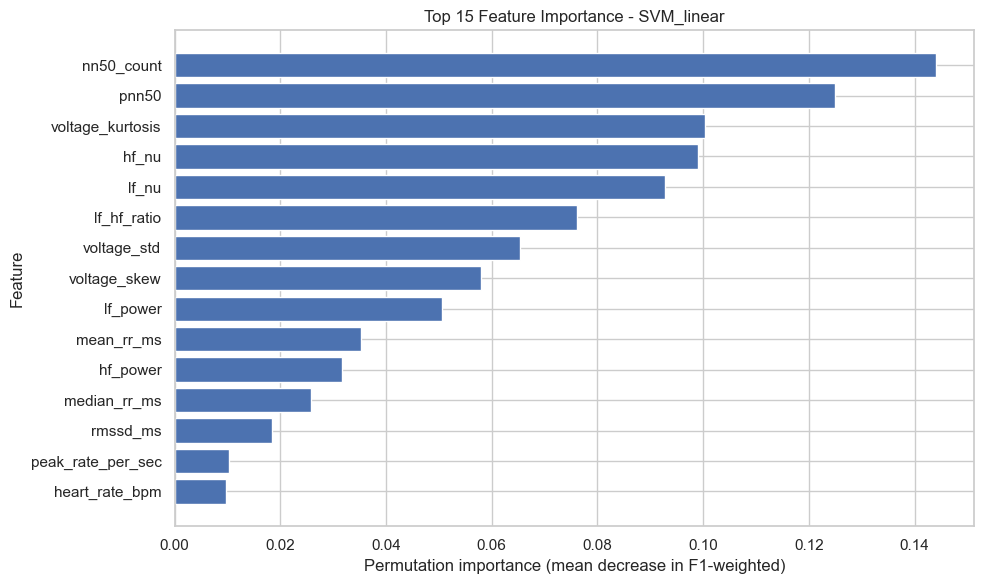

In [ ]:
from sklearn.inspection import permutation_importance

if "best_model" not in globals() or best_model is None:
    raise ValueError("Khong tim thay best_model. Hay chay cell train/evaluate truoc.")

# Permutation importance tren tap test, scale theo giam metric khi xao tron feature.
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring="f1_weighted",
    n_jobs=-1,
)

perm_importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
        "importance_abs": np.abs(perm.importances_mean),
    })
    .sort_values("importance_abs", ascending=False)
    .reset_index(drop=True)
)

TOP_N_FEATURES = 15
print(f"\nTop {TOP_N_FEATURES} features by permutation importance (model={best_model_name}):")
display(perm_importance_df[["feature", "importance_mean", "importance_std"]].head(TOP_N_FEATURES))

plt.figure(figsize=(10, 6))
plot_df = perm_importance_df.head(TOP_N_FEATURES).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation importance (mean decrease in F1-weighted)")
plt.ylabel("Feature")
plt.title(f"Top {TOP_N_FEATURES} Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

# Optional: hien thi feature_importances_ neu model cuoi co ho tro.
if hasattr(best_model, "named_steps") and "model" in best_model.named_steps:
    core_model = best_model.named_steps["model"]
    if hasattr(core_model, "feature_importances_"):
        try:
            transformed_names = best_model.named_steps["preprocessor"].get_feature_names_out()
            model_importance_df = (
                pd.DataFrame({
                    "feature": transformed_names,
                    "importance": core_model.feature_importances_,
                })
                .sort_values("importance", ascending=False)
                .reset_index(drop=True)
            )
            print("\nModel-native feature_importances_ (top 15 transformed features):")
            display(model_importance_df.head(15))
        except Exception as ex:
            print(f"Khong the truy xuat transformed feature names: {ex}")

In [ ]:
import numpy as np
import math


def gini(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)


class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # leaf


class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.n_classes = len(np.unique(y))
        self.n_features = X.shape[1]
        self.root = self._grow_tree(X, y)

    def _best_split(self, X, y):
        best_gini = float("inf")
        split_idx, split_thr = None, None

        features = np.random.choice(
            self.n_features,
            self.max_features if self.max_features else self.n_features,
            replace=False,
        )

        for feature in features:
            thresholds = np.unique(X[:, feature])
            for thr in thresholds:
                left = y[X[:, feature] <= thr]
                right = y[X[:, feature] > thr]

                if len(left) == 0 or len(right) == 0:
                    continue

                g = (len(left) * gini(left) + len(right) * gini(right)) / len(y)

                if g < best_gini:
                    best_gini = g
                    split_idx = feature
                    split_thr = thr

        return split_idx, split_thr

    def _grow_tree(self, X, y, depth=0):
        num_samples = len(y)
        num_labels = len(np.unique(y))

        # stopping conditions
        if depth >= self.max_depth or num_labels == 1 or num_samples < self.min_samples_split:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        feat, thr = self._best_split(X, y)
        if feat is None:
            return Node(value=np.bincount(y).argmax())

        left_idx = X[:, feat] <= thr
        right_idx = X[:, feat] > thr

        left = self._grow_tree(X[left_idx], y[left_idx], depth + 1)
        right = self._grow_tree(X[right_idx], y[right_idx], depth + 1)

        return Node(feat, thr, left, right)

    def _predict(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict(x, node.left)
        return self._predict(x, node.right)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict(x, self.root) for x in X])


class RandomForest:
    def __init__(self, n_estimators, max_depth, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.trees = []
        self.classes_ = np.unique(y)
        n_samples = len(y)
        max_features = int(math.sqrt(X.shape[1]))

        rng = np.random.RandomState(self.random_state) if self.random_state is not None else np.random

        for _ in range(self.n_estimators):
            # bootstrap (sample rows)
            idx = rng.choice(n_samples, n_samples, replace=True)
            X_sample = X[idx]
            y_sample = y[idx]

            tree = DecisionTree(
                max_depth=self.max_depth,
                max_features=max_features
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        X = np.asarray(X)
        preds = np.array([tree.predict(X) for tree in self.trees])
        return np.array([
            np.bincount(preds[:, i]).argmax()
            for i in range(X.shape[0])
        ])

    def predict_proba(self, X):
        X = np.asarray(X)
        preds = np.array([tree.predict(X) for tree in self.trees])
        proba = np.zeros((X.shape[0], len(self.classes_)), dtype=float)
        class_to_idx = {c: i for i, c in enumerate(self.classes_)}
        for i in range(X.shape[0]):
            votes = preds[:, i]
            for v in votes:
                proba[i, class_to_idx[v]] += 1.0
        proba /= max(len(self.trees), 1)
        return proba

In [ ]:
def run_random_forest(X_train, y_train, X_test, y_test,
                      n_estimators=50,
                      max_depth=10,
                      random_state=42):
    """
    Train + evaluate Random Forest (from scratch)
    """

    rf = RandomForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
    )

    import time
    start = time.time()
    rf.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = rf.predict(X_test)
    test_time = time.time() - start

    y_true = np.asarray(y_test)
    y_pred = np.asarray(y_pred)

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    r_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro_val = f1_score(y_true, y_pred, average="macro", zero_division=0)
    p_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    r_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_weighted_val = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    spec_macro = _specificity_macro(y_true, y_pred)

    roc_auc = np.nan
    pr_auc = np.nan
    try:
        y_proba = rf.predict_proba(X_test)
        classes = np.unique(y_true)
        if len(classes) == 2:
            pos_idx = 1 if y_proba.shape[1] > 1 else 0
            score_pos = y_proba[:, pos_idx]
            roc_auc = roc_auc_score(y_true, score_pos)
            pr_auc = average_precision_score(y_true, score_pos)
        else:
            y_bin = label_binarize(y_true, classes=classes)
            roc_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
            pr_auc = average_precision_score(y_bin, y_proba, average="weighted")
    except Exception:
        pass

    print("\n===== Random Forest (Scratch) =====")
    print(f"n_estimators={n_estimators}, max_depth={max_depth}, random_state={random_state}")
    print(f"Train time: {train_time:.4f}s | Test time: {test_time:.4f}s")
    print(
        f"ACC={acc:.4f} | BAL_ACC={bal_acc:.4f} | "
        f"Precision_macro={p_macro:.4f} | Recall_macro={r_macro:.4f} | "
        f"Precision_w={p_weighted:.4f} | Recall_w={r_weighted:.4f} | "
        f"F1_macro={f1_macro_val:.4f} | F1_weighted={f1_weighted_val:.4f} | "
        f"Spec_macro={spec_macro:.4f} | MCC={mcc:.4f} | Kappa={kappa:.4f} | "
        f"ROC_AUC={roc_auc:.4f} | PR_AUC={pr_auc:.4f}"
    )

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return rf, y_pred

In [ ]:
# rf_model, y_pred = run_random_forest(
#     X_train_model,
#     y_train_model,
#     X_test,
#     y_test,
#     n_estimators=150,
#     max_depth=14
# )

In [ ]:
# Quick summary after training
summary_cols = [
    "model", "accuracy", "balanced_accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted",
    "specificity_macro", "mcc", "cohen_kappa",
    "roc_auc", "pr_auc", "train_seconds",
    "cv_best_score", "cv_mode",
]

rank_metric = RANK_METRIC if "RANK_METRIC" in globals() else "f1_weighted"
missing = [c for c in summary_cols if c not in results_df.columns]
print("Missing metric columns:", missing if missing else "None")
print(f"\nTop models by {rank_metric}:")
display(results_df[summary_cols].sort_values(rank_metric, ascending=False).head(5))

print("\nBest model overall:")
display(results_df.sort_values(rank_metric, ascending=False).head(1))

Missing metric columns: None

Top models by f1_weighted:


,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,specificity_macro,mcc,cohen_kappa,roc_auc,pr_auc,train_seconds,cv_best_score,cv_mode
0,SVM_linear,0.972222,0.957672,0.965557,0.957672,0.961465,0.971970,0.972222,0.971992,0.990222,0.958201,0.958124,NaN,NaN,0.11,0.9647,GroupKFold
1,LDA,0.958333,0.960648,0.941964,0.960648,0.949968,0.961682,0.958333,0.959048,0.987492,0.938811,0.938091,0.998245,0.992920,0.06,0.9484,GroupKFold
2,LogisticRegression,0.958333,0.944940,0.958134,0.944940,0.951273,0.958015,0.958333,0.957942,0.983277,0.937210,0.936980,0.995646,0.986813,0.46,0.9453,GroupKFold
3,RandomForest,0.944444,0.921462,0.928048,0.921462,0.924637,0.944333,0.944444,0.944295,0.980601,0.916339,0.916267,0.994781,0.982860,3.95,0.9513,GroupKFold
4,KNN_basic,0.923611,0.888724,0.890197,0.888724,0.888866,0.924671,0.923611,0.923748,0.975788,0.885460,0.885267,0.985425,0.963117,4.46,0.9508,GroupKFold



Best model overall:


,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,specificity_macro,mcc,cohen_kappa,roc_auc,pr_auc,train_seconds,cv_best_score,best_params,cv_mode
0,SVM_linear,0.972222,0.957672,0.965557,0.957672,0.961465,0.97197,0.972222,0.971992,0.990222,0.958201,0.958124,NaN,NaN,0.11,0.9647,{'model__C': 2.0},GroupKFold
